In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav_data = pd.read_csv('../data/processed/cleaned_nav_history.csv')
scheme_perf = pd.read_csv('../data/processed/cleaned_scheme_performance.csv')
investor_data = pd.read_csv('../data/processed/cleaned_investor_transactions.csv')
portfolio_data = pd.read_csv('../data/processed/cleaned_09_portfolio_holdings.csv')

print(nav_data.shape)
print(scheme_perf.shape)
print(investor_data.shape)
print(portfolio_data.shape)

(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [3]:
print(nav_data.columns)
print(scheme_perf.columns)
print(investor_data.columns)
print(portfolio_data.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
# Convert date
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Sort values
nav_data = nav_data.sort_values(['amfi_code', 'date'])

# Daily returns
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

# Remove NaN
returns_df = nav_data.dropna(subset=['daily_return'])

# VaR and CVaR calculation
var_results = []

for code, group in returns_df.groupby('amfi_code'):

    var95 = np.percentile(group['daily_return'], 5)

    cvar95 = group[group['daily_return'] <= var95]['daily_return'].mean()

    var_results.append({
        'amfi_code': code,
        'VaR_95': var95,
        'CVaR_95': cvar95
    })

var_cvar_report = pd.DataFrame(var_results)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar_report.to_csv(
    '../reports/var_cvar_report.csv',
    index=False
)

print("Saved Successfully")

Saved Successfully


In [6]:
var_cvar_report.sort_values(
    'VaR_95'
).head()

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [7]:
# Daily returns already calculated

rolling_sharpe_df = returns_df.copy()

rolling_sharpe_df['rolling_sharpe'] = (
    rolling_sharpe_df.groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN


In [9]:
top5_funds = scheme_perf.nlargest(
    5,
    'aum_crore'
)['amfi_code'].tolist()

top5_funds

[148568, 120842, 118634, 149322, 102886]

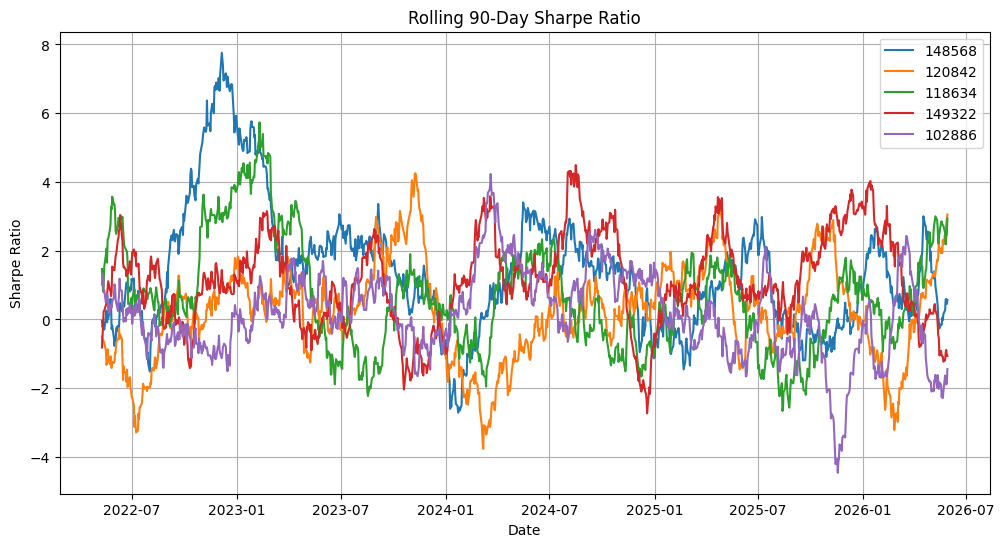

In [10]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code']==fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)

plt.savefig(
    '../reports/charts/rolling_sharpe_chart.png',
    bbox_inches='tight'
)

plt.show()

In [13]:
investor_data['transaction_date'] = pd.to_datetime(
    investor_data['transaction_date']
)

# First transaction year
cohort = investor_data.groupby('investor_id')[
    'transaction_date'
].min().dt.year.reset_index()

cohort.columns = ['investor_id','cohort_year']

investor_data = investor_data.merge(
    cohort,
    on='investor_id'
)

In [14]:
cohort_analysis = investor_data.groupby(
    'cohort_year'
).agg(
    avg_sip_amount=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
).reset_index()

cohort_analysis

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [15]:
top_fund_pref = investor_data.groupby(
    ['cohort_year','amfi_code']
).size().reset_index(name='count')

top_fund_pref = top_fund_pref.loc[
    top_fund_pref.groupby('cohort_year')['count'].idxmax()
]

top_fund_pref

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [16]:
sip_txns = investor_data[
    investor_data['transaction_type']=="SIP"
].copy()

sip_txns = sip_txns.sort_values(
    ['investor_id','transaction_date']
)

sip_txns['gap_days'] = sip_txns.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip_summary = sip_txns.groupby(
    'investor_id'
).agg(
    num_sip=('transaction_date','count'),
    avg_gap_days=('gap_days','mean')
).reset_index()

sip_summary = sip_summary[
    sip_summary['num_sip']>=6
]

sip_summary['status'] = np.where(
    sip_summary['avg_gap_days']>35,
    'At-Risk',
    'Active'
)

sip_summary.head()

,investor_id,num_sip,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk
